# 02 Exploratory Data Analysis

## Project Context
This notebook explores customer behavior patterns in the cleaned Netflix churn dataset.

## Objectives
- Understand the distribution of numeric and categorical variables
- Compare active and churned users
- Identify potential churn drivers
- Summarize the most important exploratory insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Cleaned Dataset

In [2]:
data_path = "../data/processed/netflix_churn_cleaned.csv"
df_eda = pd.read_csv(data_path)

df_eda.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


## 2. Data understanding


In [3]:
print("Dataset shape:", df_eda.shape)
print("\nColumn names:")
print(df_eda.columns)

Dataset shape: (5000, 13)

Column names:
Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'churned', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre'],
      dtype='object')


In [4]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   gender                  5000 non-null   object 
 2   subscription_type       5000 non-null   object 
 3   watch_hours             5000 non-null   float64
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   object 
 6   device                  5000 non-null   object 
 7   monthly_fee             5000 non-null   float64
 8   churned                 5000 non-null   int64  
 9   payment_method          5000 non-null   object 
 10  number_of_profiles      5000 non-null   int64  
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(6)
memory usage: 507.9+ KB


## 3. Separate Numeric and Categorical Variables

In [5]:
numeric_columns = df_eda.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df_eda.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric columns:{numeric_columns}")


print(f"Categorical columns:{categorical_columns}")


Numeric columns:['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'churned', 'number_of_profiles', 'avg_watch_time_per_day']
Categorical columns:['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']


## 4. Univariate Analysis: Numeric Variables
We examine the distribution of numeric features using histograms.

In [6]:
numeric_features = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]

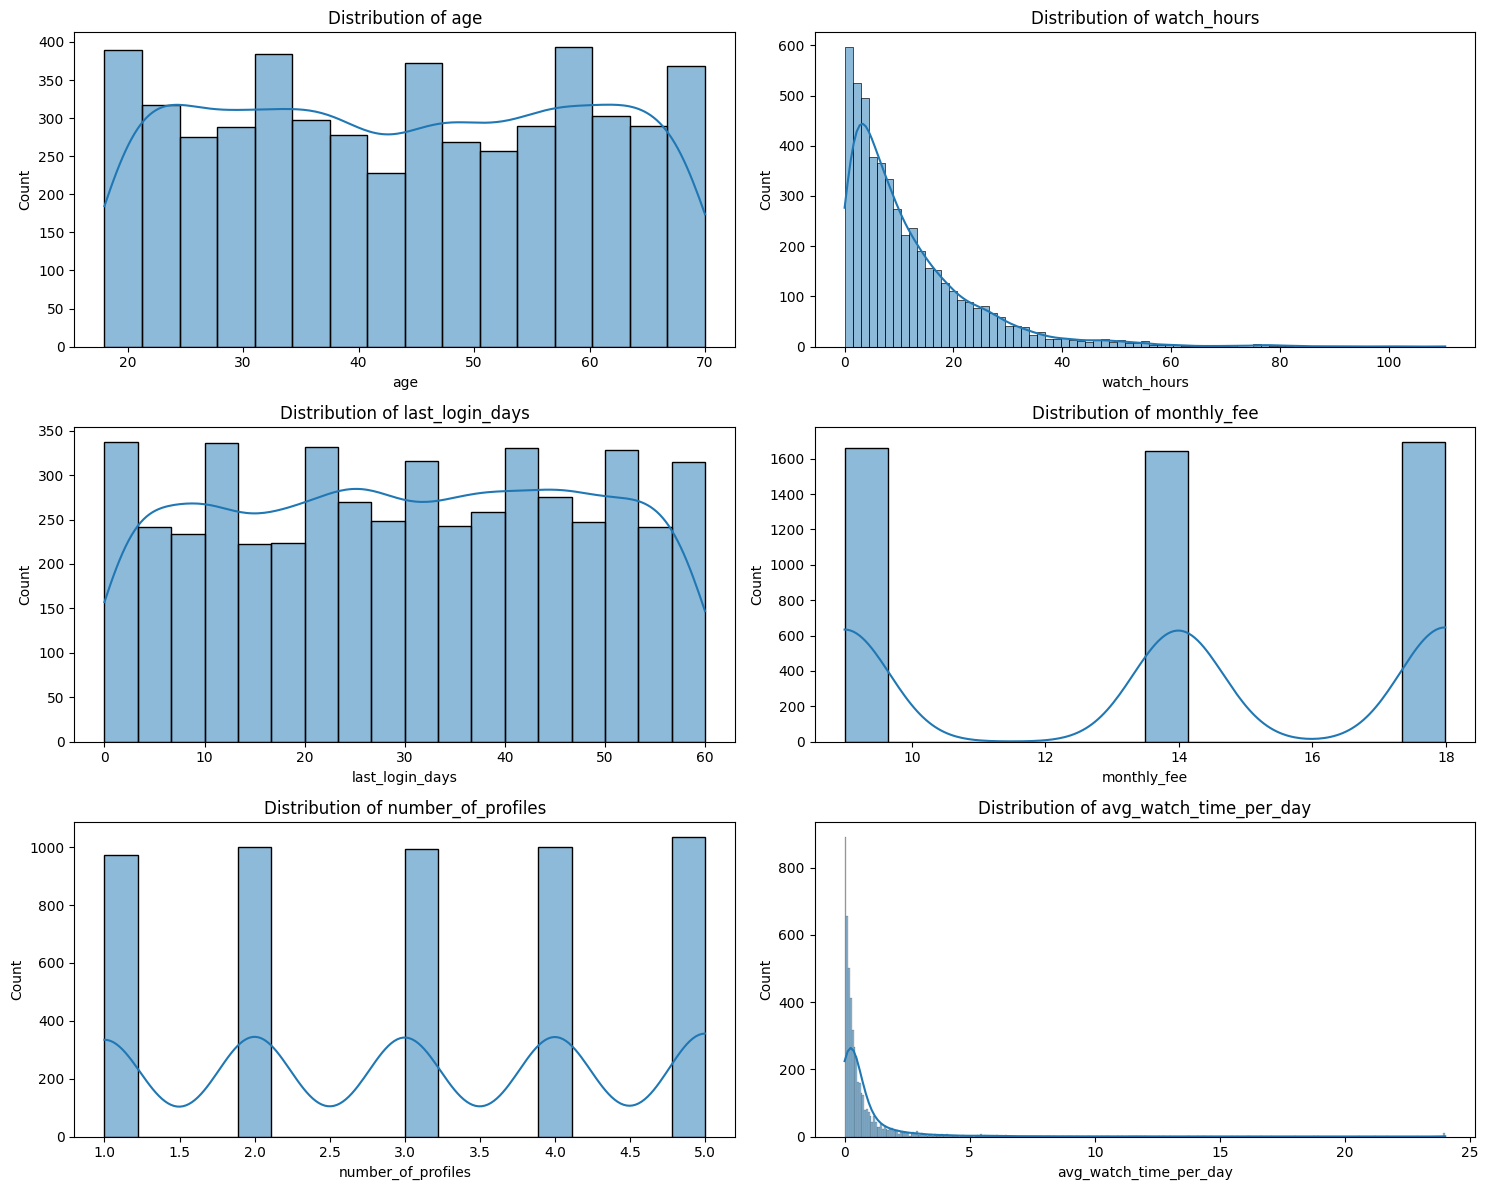

In [7]:
plt.figure(figsize=(15, 12))

for i, column in enumerate(numeric_features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df_eda[column], kde=True)
    plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

## 5. Univariate Analysis: Categorical Variables
We examine the distribution of categorical features using count plots.

In [8]:
categorical_features = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]

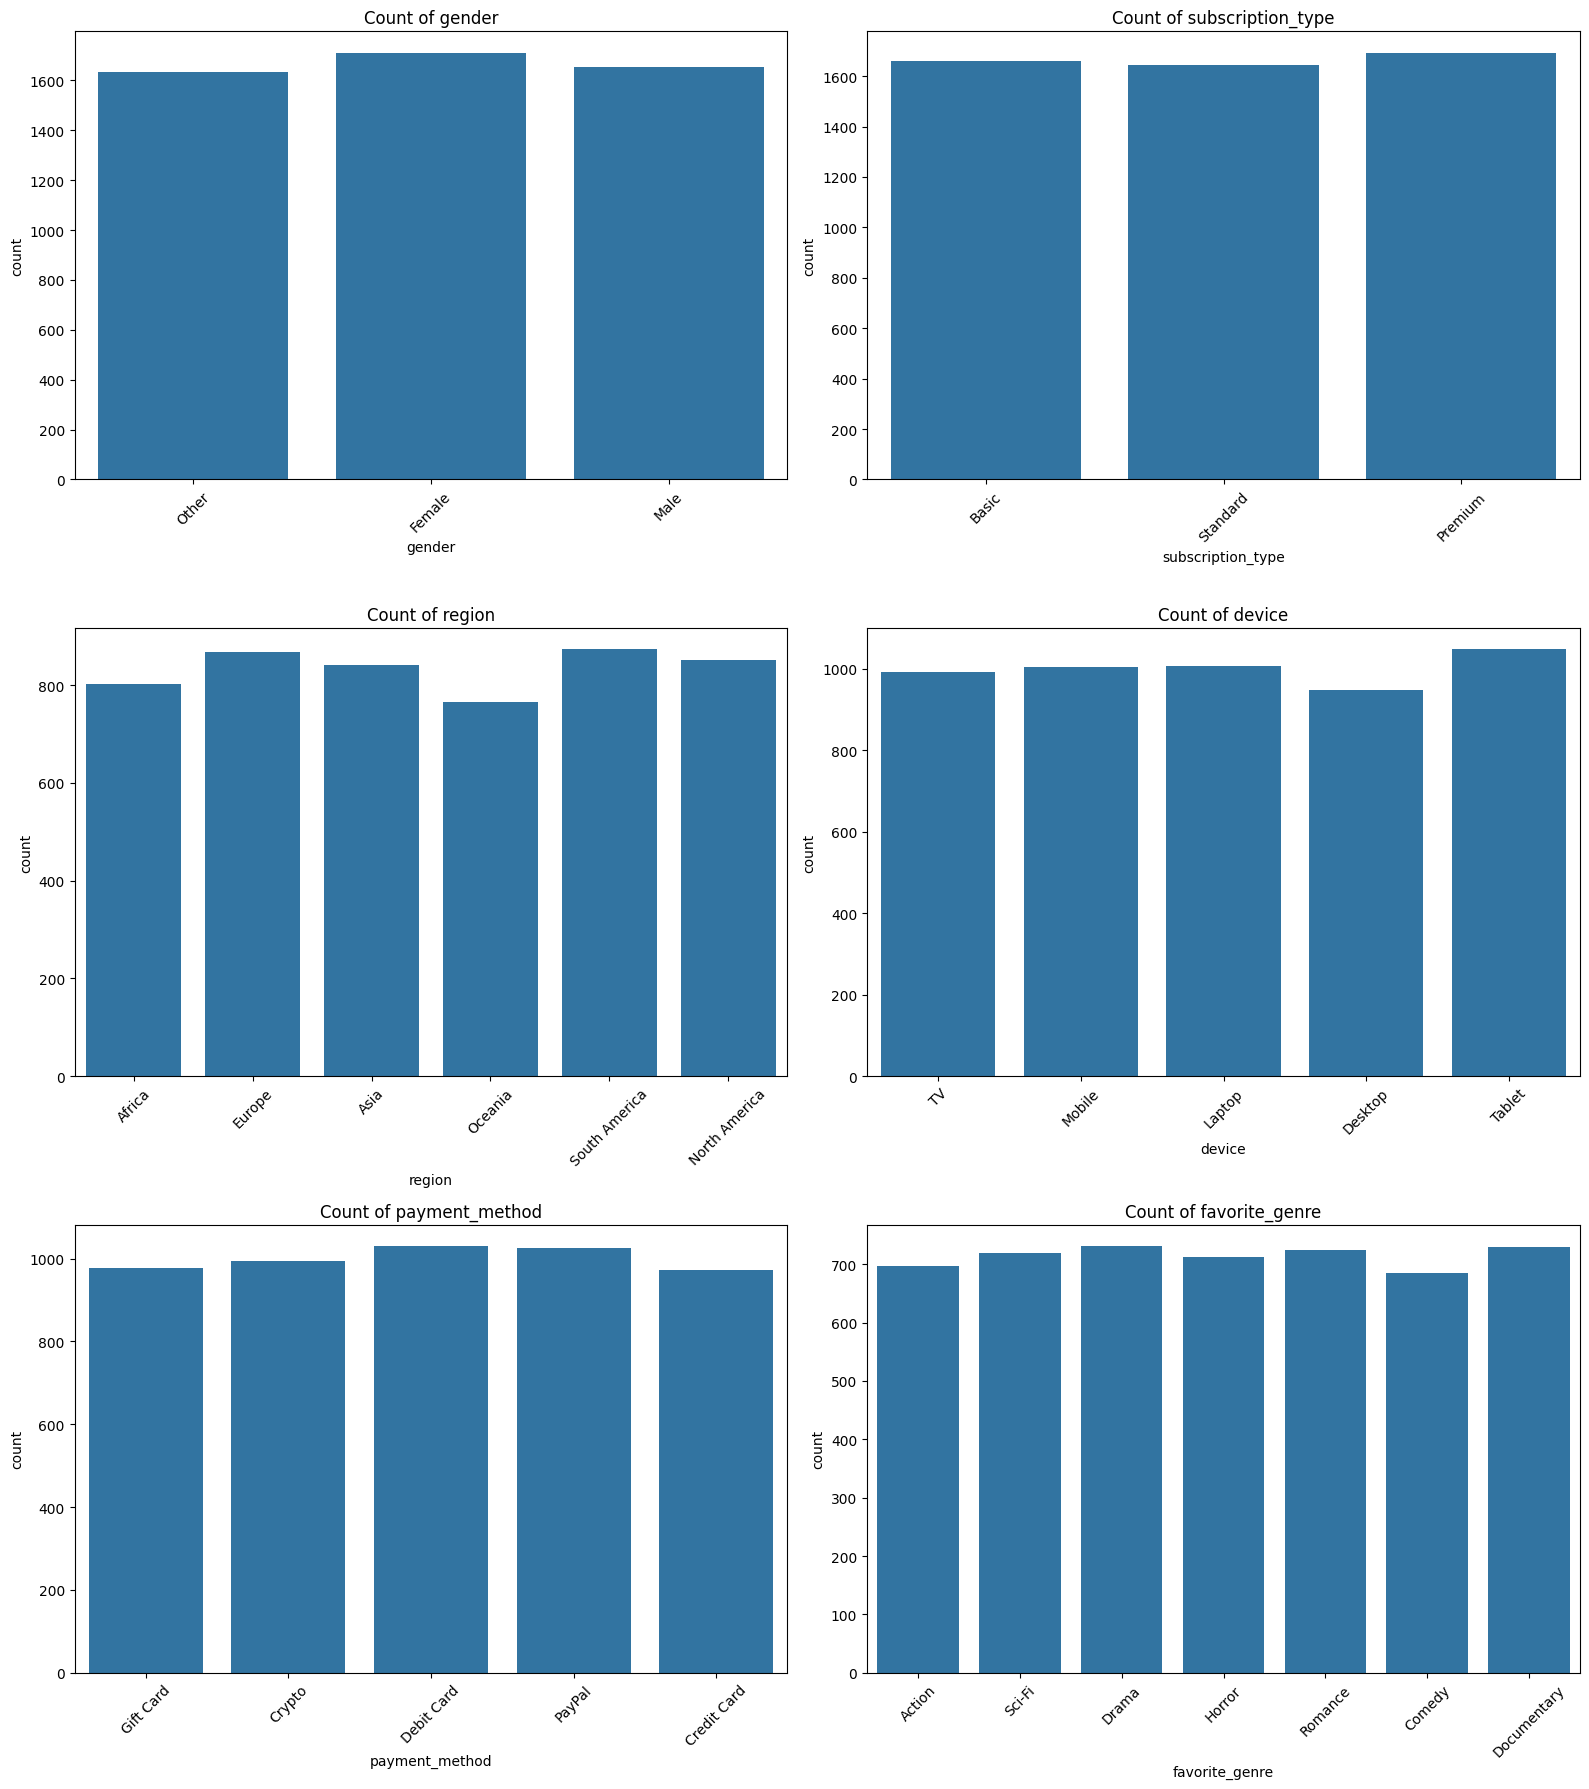

In [9]:
plt.figure(figsize=(16, 18))

for i, column in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df_eda, x=column)
    plt.title(f"Count of {column}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Target Variable Distribution
This step helps us understand whether the churn classes are balanced.

In [10]:
target_counts = df_eda["churned"].value_counts().sort_index()
target_ratios = df_eda["churned"].value_counts(normalize=True).sort_index()

print(f"Target counts:{target_counts}")

print(f"\nTarget ratios:{target_ratios}")

Target counts:churned
0    2485
1    2515
Name: count, dtype: int64

Target ratios:churned
0    0.497
1    0.503
Name: proportion, dtype: float64


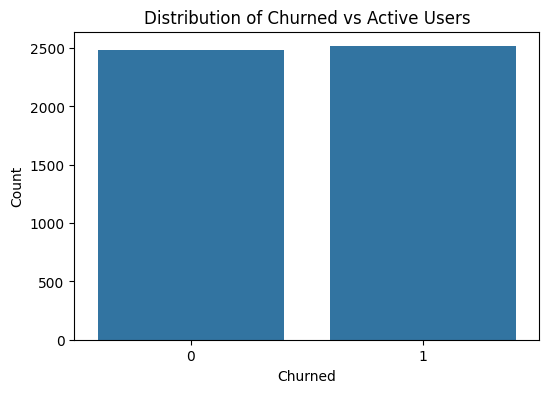

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x="churned")
plt.title("Distribution of Churned vs Active Users")
plt.xlabel("Churned")
plt.ylabel("Count")
plt.show()

## 7. Bivariate Analysis: Churn vs Subscription Type
We compare churn rate across subscription plans.

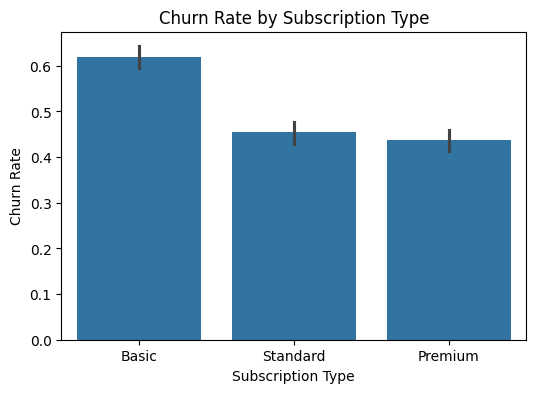

In [12]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_eda, x="subscription_type", y="churned")
plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate")
plt.show()

## 8. Bivariate Analysis: Watch Hours vs Churn
We compare monthly watch hours between active and churned users.

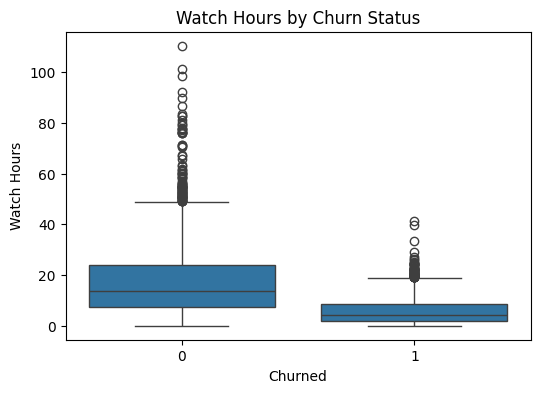

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_eda, x="churned", y="watch_hours")
plt.title("Watch Hours by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Watch Hours")
plt.show()

## 9. Bivariate Analysis: Last Login Days vs Churn
We compare inactivity levels between active and churned users.

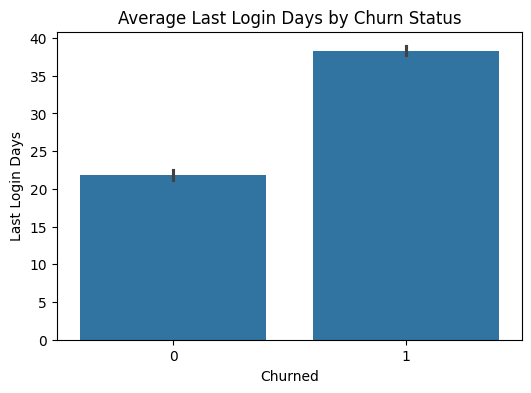

In [14]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_eda, x="churned", y="last_login_days")
plt.title("Average Last Login Days by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Last Login Days")
plt.show()

## 10. Bivariate Analysis: Average Watch Time per Day vs Churn
We compare average daily engagement between active and churned users.

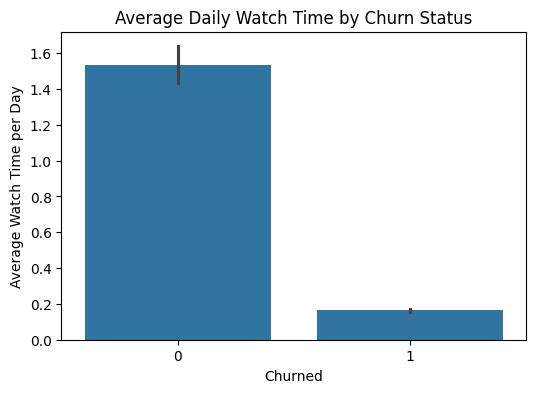

In [15]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_eda, x="churned", y="avg_watch_time_per_day")
plt.title("Average Daily Watch Time by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Average Watch Time per Day")
plt.show()

## 11. Bivariate Analysis: Monthly Fee vs Churn
We compare monthly fee levels between active and churned users.

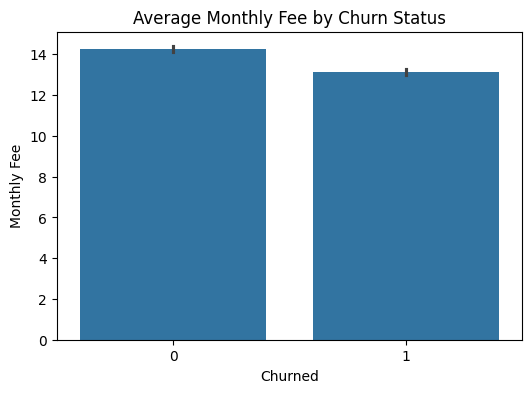

In [16]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_eda, x="churned", y="monthly_fee")
plt.title("Average Monthly Fee by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Monthly Fee")
plt.show()

## 12. Descriptive Statistics by Churn Status
This table helps compare average feature values across active and churned users.

In [17]:
churn_group_summary = df_eda.groupby("churned")[
    ["watch_hours", "last_login_days", "avg_watch_time_per_day", "monthly_fee", "number_of_profiles", "age"]
].mean().T

churn_group_summary

churned,0,1
watch_hours,17.449590,5.918497
last_login_days,21.771026,38.309344
avg_watch_time_per_day,1.534153,0.164048
monthly_fee,14.248350,13.125189
number_of_profiles,3.250302,2.801193
age,43.902213,43.793241


## 13. Key EDA Insights

### Insight 1: Engagement is the strongest churn signal
Users with lower watch hours and lower average daily watch time are much more likely to churn.

### Insight 2: Inactivity is strongly associated with churn
Churned users tend to have a much higher number of last login days, suggesting that inactivity is an important warning sign.

### Insight 3: Basic plan users show higher churn
The churn rate is highest among Basic plan users, while Standard and Premium users appear more stable.

### Insight 4: Household-style accounts are slightly more stable
Users with more profiles tend to be somewhat less likely to churn, suggesting that shared accounts may have stronger retention.

### Insight 5: Demographic variables appear less important
Compared with behavioral features, variables such as age show weaker differences between churned and active users.

## 14. EDA Summary
Overall, the exploratory analysis suggests that churn is mainly driven by user behavior rather than demographics.
The most important risk signals are:
- low engagement
- long inactivity
- lower subscription tier

These findings support the use of behavioral variables in the predictive modeling stage.